In [ ]:
# import sys
# import torchvision.transforms.functional as F

# sys.modules["torchvision.transforms.functional_tensor"] = F

In [ ]:
import os
import json
import importlib
import subprocess
import sys
import contextlib
from dataclasses import dataclass
from typing import Optional, List, Tuple, Any, Union

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, PNDMScheduler
from diffusers.utils.torch_utils import randn_tensor



import importlib
import subprocess
import sys
import contextlib
import types
from dataclasses import dataclass
from typing import Any, List, Tuple, Union, Optional

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

import t2v_metrics


# =========================================================
# utils
# =========================================================
# def _load_t2v_metrics(auto_install: bool = False) -> Any:
#     try:
#         return importlib.import_module("t2v_metrics")
#     except ModuleNotFoundError as e:
#         if not auto_install:
#             raise ModuleNotFoundError(
#                 "Package `t2v_metrics` is not installed.\n"
#                 "Install it with:\n"
#                 "pip install git+https://github.com/linzhiqiu/t2v_metrics.git"
#             ) from e

#         subprocess.check_call(
#             [
#                 sys.executable,
#                 "-m",
#                 "pip",
#                 "install",
#                 "git+https://github.com/linzhiqiu/t2v_metrics.git",
#             ]
#         )
#         return importlib.import_module("t2v_metrics")


def _to_bchw_float01(image: Union[Image.Image, np.ndarray, torch.Tensor]) -> torch.Tensor:
    """
    Returns [B,3,H,W] float tensor in [0,1].
    Keeps graph if input is torch.Tensor.
    """
    if isinstance(image, Image.Image):
        image = np.array(image.convert("RGB"))

    if isinstance(image, np.ndarray):
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)
        if image.ndim != 3:
            raise ValueError("NumPy image must have shape [H,W,C] or [H,W].")
        image = torch.from_numpy(image)

    if not isinstance(image, torch.Tensor):
        raise TypeError("image must be PIL.Image, np.ndarray or torch.Tensor")

    x = image

    if x.ndim == 2:
        x = x.unsqueeze(0).repeat(3, 1, 1)
    elif x.ndim == 3:
        # HWC -> CHW if needed
        if x.shape[0] not in (1, 3) and x.shape[-1] in (1, 3):
            x = x.permute(2, 0, 1)
    elif x.ndim == 4:
        pass
    else:
        raise ValueError(f"Unsupported image ndim={x.ndim}")

    if x.ndim == 3:
        x = x.unsqueeze(0)

    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)

    x = x.float()
    if x.max() > 1.0:
        x = x / 255.0
    x = x.clamp(0.0, 1.0)
    return x


def _pad_to_square_bchw(
    x: torch.Tensor,
    fill: Tuple[float, float, float],
) -> torch.Tensor:
    """
    x: [B,3,H,W] in [0,1]
    differentiable constant padding to square
    """
    if x.ndim != 4 or x.shape[1] != 3:
        raise ValueError("Expected BCHW tensor with 3 channels.")

    b, c, h, w = x.shape
    if h == w:
        return x

    side = max(h, w)
    pad_h = side - h
    pad_w = side - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    out = x.new_empty((b, c, side, side))
    for ch in range(3):
        out[:, ch].fill_(fill[ch])

    out[:, :, pad_top:pad_top + h, pad_left:pad_left + w] = x
    return out


@dataclass
class VQAEvalResult:
    score: torch.Tensor   # [B]
    ce: torch.Tensor      # [B]


# =========================================================
# Differentiable scorer
# =========================================================
class DifferentiableVQAScorer(torch.nn.Module):
    """
    True differentiable VQA scorer for CLIP-FlanT5.

    Important:
      - does NOT call t2v_metrics.CLIPT5Model.forward()
      - patches vision tower forward to remove internal no_grad
      - keeps model params frozen, but gradients flow to image input
    """
    def __init__(
        self,
        model_name: str = "clip-flant5-xl",
        device: str = "cuda:0",
        # auto_install: bool = False,
        use_autocast: bool = True,
    ) -> None:
        super().__init__()

        # _load_t2v_metrics(auto_install=auto_install)

        clip_t5_mod = importlib.import_module(
            "t2v_metrics.models.vqascore_models.clip_t5_model"
        )

        self.CLIPT5Model = clip_t5_mod.CLIPT5Model
        self.format_question = clip_t5_mod.format_question
        self.format_answer = clip_t5_mod.format_answer
        self.t5_tokenizer_image_token = clip_t5_mod.t5_tokenizer_image_token
        self.IGNORE_INDEX = clip_t5_mod.IGNORE_INDEX

        self.device = torch.device(device)
        self.use_autocast = use_autocast and self.device.type == "cuda"

        # load official wrapper only as a loader/container
        self.backend = self.CLIPT5Model(model_name=model_name, device=device)

        self.model = self.backend.model
        self.tokenizer = self.backend.tokenizer
        self.image_processor = self.backend.image_processor
        self.conversational_style = self.backend.conversational_style
        self.image_aspect_ratio = self.backend.image_aspect_ratio

        self.model.eval()
        for p in self.model.parameters():
            p.requires_grad_(False)

        # patch the vision tower so grads can flow through image
        self._patch_vision_tower_forward()

        self.register_buffer(
            "image_mean",
            torch.tensor(self.image_processor.image_mean, dtype=torch.float32).view(1, 3, 1, 1),
            persistent=False,
        )
        self.register_buffer(
            "image_std",
            torch.tensor(self.image_processor.image_std, dtype=torch.float32).view(1, 3, 1, 1),
            persistent=False,
        )

        crop_size = getattr(self.image_processor, "crop_size", None)
        size = getattr(self.image_processor, "size", None)

        if isinstance(crop_size, dict):
            target_h = crop_size.get("height", crop_size.get("shortest_edge", 336))
            target_w = crop_size.get("width", crop_size.get("shortest_edge", 336))
        elif isinstance(size, dict):
            target_h = size.get("height", size.get("shortest_edge", 336))
            target_w = size.get("width", size.get("shortest_edge", 336))
        elif isinstance(size, int):
            target_h = target_w = size
        else:
            target_h = target_w = 336

        self.target_size = (int(target_h), int(target_w))

    def _autocast_context(self):
        if self.use_autocast:
            return torch.autocast(device_type="cuda", dtype=torch.bfloat16)
        return contextlib.nullcontext()

    def _patch_vision_tower_forward(self) -> None:
        """
        Replace CLIPVisionTower.forward (which is wrapped in @torch.no_grad())
        with a differentiable version.
        """
        vision_tower = self.model.get_vision_tower()

        def differentiable_forward(this, images):
            if isinstance(images, list):
                image_features = []
                for image in images:
                    image_forward_out = this.vision_tower(
                        image.to(device=this.device, dtype=this.dtype).unsqueeze(0),
                        output_hidden_states=True,
                    )
                    image_feature = this.feature_select(image_forward_out).to(image.dtype)
                    image_features.append(image_feature)
                return image_features
            else:
                image_forward_outs = this.vision_tower(
                    images.to(device=this.device, dtype=this.dtype),
                    output_hidden_states=True,
                )
                image_features = this.feature_select(image_forward_outs).to(images.dtype)
                return image_features

        vision_tower.forward = types.MethodType(differentiable_forward, vision_tower)

    def preprocess_tensor_image(
        self,
        image: Union[Image.Image, np.ndarray, torch.Tensor],
    ) -> torch.Tensor:
        """
        Returns normalized BCHW tensor for CLIP image tower.
        Fully differentiable for torch.Tensor input.
        """
        x = _to_bchw_float01(image).to(self.device)

        if self.image_aspect_ratio == "pad":
            fill = tuple(float(v) for v in self.image_processor.image_mean)
            x = _pad_to_square_bchw(x, fill=fill)

        interpolate_kwargs = dict(
            size=self.target_size,
            mode="bilinear",
            align_corners=False,
        )
        if "antialias" in F.interpolate.__code__.co_varnames:
            interpolate_kwargs["antialias"] = True

        x = F.interpolate(x, **interpolate_kwargs)
        x = (x - self.image_mean.to(x.device, x.dtype)) / self.image_std.to(x.device, x.dtype)
        return x

    def _build_inputs_and_labels(
        self,
        batch_size: int,
        prompt: Union[str, List[str]],
        question_template: str,
        answer_template: str,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        if isinstance(prompt, str):
            texts = [prompt] * batch_size
        else:
            texts = list(prompt)

        if len(texts) != batch_size:
            raise ValueError("Number of prompts must match batch size.")

        questions = [question_template.format(text) for text in texts]
        answers = [answer_template.format(text) for text in texts]

        questions = [
            self.format_question(q, conversation_style=self.conversational_style)
            for q in questions
        ]
        answers = [
            self.format_answer(a, conversation_style=self.conversational_style)
            for a in answers
        ]

        input_ids = [
            self.t5_tokenizer_image_token(q, self.tokenizer, return_tensors="pt")
            for q in questions
        ]
        labels = [
            self.t5_tokenizer_image_token(a, self.tokenizer, return_tensors="pt")
            for a in answers
        ]

        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids,
            batch_first=True,
            padding_value=self.tokenizer.pad_token_id,
        )
        labels = torch.nn.utils.rnn.pad_sequence(
            labels,
            batch_first=True,
            padding_value=self.IGNORE_INDEX,
        )

        input_ids = input_ids[:, : self.tokenizer.model_max_length].to(self.device)
        labels = labels[:, : self.tokenizer.model_max_length].to(self.device)

        attention_mask = input_ids.ne(self.tokenizer.pad_token_id).to(self.device)
        decoder_attention_mask = labels.ne(self.IGNORE_INDEX).to(self.device)

        return input_ids, attention_mask, decoder_attention_mask, labels

    def evaluate(
        self,
        image: Union[Image.Image, np.ndarray, torch.Tensor],
        prompt: Union[str, List[str]],
        question_template: str = 'Does this figure show "{}"? Please answer yes or no.',
        answer_template: str = "Yes",
    ) -> VQAEvalResult:
        """
        Returns:
            score: [B] = exp(-CE)
            ce:    [B] mean CE over valid answer tokens

        This path is differentiable w.r.t. `image` if `image` is a tensor that
        requires grad.
        """
        images = self.preprocess_tensor_image(image)
        input_ids, attention_mask, decoder_attention_mask, labels = self._build_inputs_and_labels(
            batch_size=images.shape[0],
            prompt=prompt,
            question_template=question_template,
            answer_template=answer_template,
        )

        with self._autocast_context():
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                decoder_attention_mask=decoder_attention_mask,
                labels=labels,
                images=images,
                past_key_values=None,
                inputs_embeds=None,
                use_cache=None,
                output_attentions=None,
                output_hidden_states=None,
                return_dict=True,
            )

            logits = outputs.logits  # [B, T, V]
            vocab = logits.shape[-1]

            per_token_ce = F.cross_entropy(
                logits.reshape(-1, vocab),
                labels.reshape(-1),
                ignore_index=self.IGNORE_INDEX,
                reduction="none",
            ).view(labels.shape[0], labels.shape[1])

            valid = labels.ne(self.IGNORE_INDEX)
            ce = (per_token_ce * valid).sum(dim=1) / valid.sum(dim=1).clamp(min=1)
            score = torch.exp(-ce)

        return VQAEvalResult(score=score, ce=ce)

    def score_and_ce_tensor(
        self,
        image: Union[Image.Image, np.ndarray, torch.Tensor],
        prompt: Union[str, List[str]],
        question_template: str = 'Does this figure show "{}"? Please answer yes or no.',
        answer_template: str = "Yes",
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        out = self.evaluate(
            image=image,
            prompt=prompt,
            question_template=question_template,
            answer_template=answer_template,
        )
        return out.score, out.ce

    def score_tensor(
        self,
        image: Union[Image.Image, np.ndarray, torch.Tensor],
        prompt: str,
        question_template: str = 'Does this figure show "{}"? Please answer yes or no.',
        answer_template: str = "Yes",
    ) -> torch.Tensor:
        return self.evaluate(
            image=image,
            prompt=prompt,
            question_template=question_template,
            answer_template=answer_template,
        ).score.reshape(-1)[0]

    def ce_tensor(
        self,
        image: Union[Image.Image, np.ndarray, torch.Tensor],
        prompt: str,
        question_template: str = 'Does this figure show "{}"? Please answer yes or no.',
        answer_template: str = "Yes",
    ) -> torch.Tensor:
        return self.evaluate(
            image=image,
            prompt=prompt,
            question_template=question_template,
            answer_template=answer_template,
        ).ce.reshape(-1)[0]

    @torch.no_grad()
    def score_value(
        self,
        image: Union[Image.Image, np.ndarray, torch.Tensor],
        prompt: str,
        question_template: str = 'Does this figure show "{}"? Please answer yes or no.',
        answer_template: str = "Yes",
    ) -> float:
        return float(
            self.score_tensor(
                image=image,
                prompt=prompt,
                question_template=question_template,
                answer_template=answer_template,
            ).item()
        )

# =========================================================
# 3) Загрузка Stable Diffusion 1.5
# =========================================================
MODEL_ID = "runwayml/stable-diffusion-v1-5"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

tokenizer = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(
    MODEL_ID, subfolder="text_encoder", torch_dtype=dtype
).to(device)
vae = AutoencoderKL.from_pretrained(
    MODEL_ID, subfolder="vae", torch_dtype=dtype
).to(device)
unet = UNet2DConditionModel.from_pretrained(
    MODEL_ID, subfolder="unet", torch_dtype=dtype
).to(device)
scheduler = PNDMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")

text_encoder.eval()
vae.eval()
unet.eval()


# =========================================================
# 4) Хелперы
# =========================================================
@torch.no_grad()
def encode_prompt(prompt: str, negative_prompt: str = "", max_length: int = 77):
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    uncond_inputs = tokenizer(
        negative_prompt,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

    cond_embeds = text_encoder(text_inputs.input_ids.to(device))[0]
    uncond_embeds = text_encoder(uncond_inputs.input_ids.to(device))[0]
    return cond_embeds, uncond_embeds


def decode_latents(latents: torch.Tensor) -> torch.Tensor:
    vae_dtype = next(vae.parameters()).dtype
    latents = (latents / 0.18215).to(device=vae.device, dtype=vae_dtype)
    images = vae.decode(latents).sample
    images = (images / 2 + 0.5).clamp(0, 1)
    return images


def save_image_tensor(images_bchw: torch.Tensor, path: str):
    image = images_bchw[0].detach().cpu().clamp(0, 1)
    image = (image.permute(1, 2, 0).numpy() * 255.0).round().astype(np.uint8)
    Image.fromarray(image).save(path)


def save_latents_pt(latents: torch.Tensor, path: str):
    torch.save(latents.detach().cpu(), path)


def save_json(data: dict, path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def save_diff_image(img_a: torch.Tensor, img_b: torch.Tensor, path: str, amplify: float = 4.0):
    diff = (img_b - img_a).abs()
    diff = (diff / (diff.max().clamp(min=1e-8))) * amplify
    diff = diff.clamp(0, 1)
    save_image_tensor(diff, path)


def plot_vqa_scores(step_records: List[dict], save_path: str):
    outer_ids = [r["step_index"] for r in step_records]
    before_scores = [r["vqa_score_before_gd"] for r in step_records]
    after_scores = [r["vqa_score_after_gd"] for r in step_records]

    plt.figure(figsize=(10, 5))
    plt.plot(outer_ids, before_scores, marker="o", label="before GD")
    plt.plot(outer_ids, after_scores, marker="o", label="after GD")
    plt.xlabel("denoise step_index")
    plt.ylabel("VQA score on decoded x0")
    plt.title("VQA score before/after GD on x_t")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


def plot_inner_gd_scores(step_records: List[dict], save_path: str):
    plt.figure(figsize=(10, 5))
    has_any = False
    for r in step_records:
        gd_hist = r.get("gd_iterations", [])
        if len(gd_hist) == 0:
            continue
        xs = [g["gd_iter"] for g in gd_hist]
        ys = [g["vqa_score_x0_after_update"] for g in gd_hist]
        plt.plot(xs, ys, marker="o", label=f"step {r['step_index']}")
        has_any = True

    if has_any:
        plt.xlabel("GD iteration")
        plt.ylabel("VQA score on decoded x0")
        plt.title("Inner GD optimization trajectories")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
    plt.close()


def predict_x0_from_eps(
    x_t: torch.Tensor,
    eps_pred: torch.Tensor,
    t,
    scheduler,
) -> torch.Tensor:
    t_idx = int(t.item()) if hasattr(t, "item") else int(t)

    alpha_bar_t = scheduler.alphas_cumprod[t_idx].to(device=x_t.device, dtype=x_t.dtype)
    while alpha_bar_t.ndim < x_t.ndim:
        alpha_bar_t = alpha_bar_t.view(*alpha_bar_t.shape, 1)

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

    x0_pred = (x_t - sqrt_one_minus_alpha_bar_t * eps_pred) / sqrt_alpha_bar_t
    return x0_pred


def predict_eps_with_cfg(
    x_t: torch.Tensor,
    t,
    text_embeds: torch.Tensor,
    guidance_scale: float,
) -> torch.Tensor:
    latent_model_input = torch.cat([x_t] * 2, dim=0)
    latent_model_input = scheduler.scale_model_input(latent_model_input, t)

    noise_pred = unet(
        latent_model_input,
        t,
        encoder_hidden_states=text_embeds,
    ).sample

    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
    eps_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
    return eps_pred


# =========================================================
# 5) Вспомогательная обертка: единственное место вызова VQA
# =========================================================
def evaluate_vqa_on_image(
    vqa_scorer: DifferentiableVQAScorer,
    image: torch.Tensor,
    prompt: str,
    question_template: str,
    answer_template: str,
) -> VQAEvalResult:
    return vqa_scorer.evaluate(
        image=image,
        prompt=prompt,
        question_template=question_template,
        answer_template=answer_template,
    )

def generate_with_step_vqa_gd(
    prompt: str,
    negative_prompt: str = "",
    height: int = 512,
    width: int = 512,
    num_inference_steps: int = 30,
    guidance_scale: float = 7.5,
    seed: Optional[int] = 0,
    save_dir: str = "sd15_vqa_gd_run",
    save_every: int = 1,
    vqa_scorer: Optional[DifferentiableVQAScorer] = None,
    question_template: str = 'Does this figure show "{}"? Please answer yes or no.',
    answer_template: str = "Yes",
    gd_steps: int = 3,
    gd_lr: float = 0.05,
    clamp_xt: bool = False,
    gd_only_first_k_steps: Optional[int] = None,   # NEW
) -> Tuple[torch.Tensor, List[dict]]:
    assert height % 8 == 0 and width % 8 == 0, "height/width должны делиться на 8"

    if vqa_scorer is None:
        raise ValueError("Нужно передать vqa_scorer")

    os.makedirs(save_dir, exist_ok=True)

    steps_xt_orig_dir = os.path.join(save_dir, "steps_xt_orig")
    steps_xt_gd_dir = os.path.join(save_dir, "steps_xt_gd")
    steps_xt_delta_dir = os.path.join(save_dir, "steps_xt_gd_deltas")
    steps_latents_dir = os.path.join(save_dir, "steps_latents")

    os.makedirs(steps_xt_orig_dir, exist_ok=True)
    os.makedirs(steps_xt_gd_dir, exist_ok=True)
    os.makedirs(steps_xt_delta_dir, exist_ok=True)
    os.makedirs(steps_latents_dir, exist_ok=True)

    cond_embeds, uncond_embeds = encode_prompt(prompt, negative_prompt)
    text_embeds = torch.cat([uncond_embeds, cond_embeds], dim=0)

    scheduler.set_timesteps(num_inference_steps, device=device)

    batch_size = 1
    latent_shape = (batch_size, unet.config.in_channels, height // 8, width // 8)

    generator = None
    if seed is not None:
        generator = torch.Generator(device=device).manual_seed(seed)

    latents = randn_tensor(latent_shape, generator=generator, device=device, dtype=dtype)
    latents = latents * scheduler.init_noise_sigma

    n_digits = max(4, len(str(len(scheduler.timesteps))))
    step_records = []

    # если None -> GD на всех шагах
    if gd_only_first_k_steps is None:
        gd_only_first_k_steps = len(scheduler.timesteps)

    gd_only_first_k_steps = max(0, min(int(gd_only_first_k_steps), len(scheduler.timesteps)))

    for i, t in enumerate(scheduler.timesteps):
        t_int = int(t.item()) if hasattr(t, "item") else int(t)
        filename_base = f"step_{i:0{n_digits}d}_t{t_int}"

        x_t_orig = latents.detach().clone()

        with torch.no_grad():
            xt_orig_img = decode_latents(x_t_orig)
            xt_orig_img_path = os.path.join(steps_xt_orig_dir, f"{filename_base}_orig.png")
            xt_orig_latent_path = os.path.join(steps_latents_dir, f"{filename_base}_orig.pt")
            save_image_tensor(xt_orig_img, xt_orig_img_path)
            save_latents_pt(x_t_orig, xt_orig_latent_path)

        do_gd_this_step = i < gd_only_first_k_steps

        # -------------------------------------------------
        # score до GD — считаем как и раньше
        # -------------------------------------------------
        with torch.enable_grad():
            x_t_for_eval = x_t_orig.detach().clone().requires_grad_(True)
            eps_pred_before = predict_eps_with_cfg(
                x_t=x_t_for_eval,
                t=t,
                text_embeds=text_embeds,
                guidance_scale=guidance_scale,
            )
            x0_before = predict_x0_from_eps(x_t_for_eval, eps_pred_before, t, scheduler)
            x0_before_img = decode_latents(x0_before)

            vqa_before_result = evaluate_vqa_on_image(
                vqa_scorer=vqa_scorer,
                image=x0_before_img,
                prompt=prompt,
                question_template=question_template,
                answer_template=answer_template,
            )

        vqa_before_val = float(vqa_before_result.score.reshape(-1)[0].detach().item())

        # -------------------------------------------------
        # GD по x_t только на первых k шагах
        # -------------------------------------------------

        x_t_gd = x_t_orig.detach().clone().requires_grad_(True)
        gd_records = []

        if do_gd_this_step:
            for gd_iter in range(gd_steps):
                eps_pred = predict_eps_with_cfg(
                    x_t=x_t_gd,
                    t=t,
                    text_embeds=text_embeds,
                    guidance_scale=guidance_scale,
                )
                x0_pred = predict_x0_from_eps(
                    x_t=x_t_gd,
                    eps_pred=eps_pred,
                    t=t,
                    scheduler=scheduler,
                )
                x0_img = decode_latents(x0_pred)

                vqa_result = evaluate_vqa_on_image(
                    vqa_scorer=vqa_scorer,
                    image=x0_img,
                    prompt=prompt,
                    question_template=question_template,
                    answer_template=answer_template,
                )

                vqa_score = vqa_result.score.reshape(-1)[0]
                vqa_ce = vqa_result.ce.reshape(-1)[0]

                if not vqa_ce.requires_grad:
                    raise RuntimeError(
                        "VQA CE is detached from the graph. "
                        "Current CLIP-FlanT5 backend is not differentiable w.r.t. image."
                    )

                grad = torch.autograd.grad(
                    vqa_ce, x_t_gd, retain_graph=False, create_graph=False
                )[0]
                

                with torch.no_grad():
                    xt_before = x_t_gd.detach().clone()
                    

                    grad = grad / (grad.norm() + 1e-8)
                    
                
                    x_t_gd -= gd_lr * grad

                    if clamp_xt:
                        x_t_gd.clamp_(-4.0, 4.0)

                    xt_after = x_t_gd.detach().clone()

                    xt_img_before = decode_latents(xt_before)
                    xt_img_after = decode_latents(xt_after)

                    gd_img_path = os.path.join(
                        steps_xt_gd_dir,
                        f"{filename_base}_gd_{gd_iter:02d}.png",
                    )
                    gd_delta_img_path = os.path.join(
                        steps_xt_delta_dir,
                        f"{filename_base}_gd_{gd_iter:02d}_delta.png",
                    )
                    gd_latent_path = os.path.join(
                        steps_latents_dir,
                        f"{filename_base}_gd_{gd_iter:02d}.pt",
                    )

                    save_image_tensor(xt_img_after, gd_img_path)
                    save_diff_image(xt_img_before, xt_img_after, gd_delta_img_path)
                    save_latents_pt(xt_after, gd_latent_path)

                    eps_pred_after = predict_eps_with_cfg(
                        x_t=xt_after,
                        t=t,
                        text_embeds=text_embeds,
                        guidance_scale=guidance_scale,
                    )
                    x0_after = predict_x0_from_eps(xt_after, eps_pred_after, t, scheduler)
                    x0_after_img = decode_latents(x0_after)

                    vqa_after_update_result = evaluate_vqa_on_image(
                        vqa_scorer=vqa_scorer,
                        image=x0_after_img,
                        prompt=prompt,
                        question_template=question_template,
                        answer_template=answer_template,
                    )

                    gd_record = {
                        "gd_iter": int(gd_iter),
                        "vqa_score_x0_before_update": float(vqa_score.detach().item()),
                        "vqa_ce_x0_before_update": float(vqa_ce.detach().item()),
                        "vqa_score_x0_after_update": float(
                            vqa_after_update_result.score.reshape(-1)[0].detach().item()
                        ),
                        "vqa_ce_x0_after_update": float(
                            vqa_after_update_result.ce.reshape(-1)[0].detach().item()
                        ),
                        "grad_norm": float(grad.norm().detach().item()),
                        "xt_gd_image_path": gd_img_path,
                        "xt_gd_delta_image_path": gd_delta_img_path,
                        "xt_gd_latent_path": gd_latent_path,
                    }
                    gd_records.append(gd_record)

                x_t_gd = x_t_gd.detach().requires_grad_(True)
        else:
            x_t_gd = x_t_orig.detach().clone()


        # -------------------------------------------------
        # После GD / без GD: обычный denoise step
        # -------------------------------------------------
        with torch.no_grad():
            eps_pred_after_gd = predict_eps_with_cfg(
                x_t=x_t_gd,
                t=t,
                text_embeds=text_embeds,
                guidance_scale=guidance_scale,
            )
            x0_after_gd = predict_x0_from_eps(x_t_gd, eps_pred_after_gd, t, scheduler)
            x0_after_gd_img = decode_latents(x0_after_gd)

            vqa_after_gd_result = evaluate_vqa_on_image(
                vqa_scorer=vqa_scorer,
                image=x0_after_gd_img,
                prompt=prompt,
                question_template=question_template,
                answer_template=answer_template,
            )

            vqa_after_gd = float(vqa_after_gd_result.score.reshape(-1)[0].item())
            latents = scheduler.step(eps_pred_after_gd, t, x_t_gd).prev_sample

        should_save = (save_every > 0 and i % save_every == 0) or (i == len(scheduler.timesteps) - 1)
        if should_save:
            record = {
                "step_index": int(i),
                "timestep": t_int,
                "gd_applied": bool(do_gd_this_step),   # NEW
                "xt_orig_image_path": xt_orig_img_path,
                "xt_orig_latent_path": xt_orig_latent_path,
                "vqa_score_before_gd": float(vqa_before_val),
                "vqa_score_after_gd": float(vqa_after_gd),
                "gd_iterations": gd_records,
            }
            step_records.append(record)

            print(
                f"step={i:03d} | t={t_int:04d} | gd_applied={do_gd_this_step} | "
                f"VQA(x0 before GD)={vqa_before_val:.6f} | "
                f"VQA(x0 after GD)={vqa_after_gd:.6f}"
            )

    with torch.no_grad():
        final_images = decode_latents(latents)

        final_vqa_result = evaluate_vqa_on_image(
            vqa_scorer=vqa_scorer,
            image=final_images,
            prompt=prompt,
            question_template=question_template,
            answer_template=answer_template,
        )
        final_score = float(final_vqa_result.score.reshape(-1)[0].item())
        final_ce = float(final_vqa_result.ce.reshape(-1)[0].item())

    final_image_path = os.path.join(save_dir, "final.png")
    final_latent_path = os.path.join(save_dir, "final_latents.pt")
    plot_outer_path = os.path.join(save_dir, "vqa_scores_outer.png")
    plot_inner_path = os.path.join(save_dir, "vqa_scores_inner.png")

    save_image_tensor(final_images, final_image_path)
    save_latents_pt(latents, final_latent_path)
    plot_vqa_scores(step_records, plot_outer_path)
    plot_inner_gd_scores(step_records, plot_inner_path)

    meta = {
        "prompt": prompt,
        "negative_prompt": negative_prompt,
        "height": height,
        "width": width,
        "num_inference_steps": num_inference_steps,
        "guidance_scale": guidance_scale,
        "seed": seed,
        "gd_steps": gd_steps,
        "gd_lr": gd_lr,
        "gd_only_first_k_steps": gd_only_first_k_steps,   # NEW
        "final_image_path": final_image_path,
        "final_latent_path": final_latent_path,
        "final_vqa_score": final_score,
        "final_vqa_ce": final_ce,
        "plot_outer_path": plot_outer_path,
        "plot_inner_path": plot_inner_path,
        "steps": step_records,
    }

    save_json(meta, os.path.join(save_dir, "scores.json"))
    return final_images, step_records

# =========================================================
# 7) Пример запуска
# =========================================================
prompt = "a mushroom with a broken stem in the forest"
negative_prompt = "low quality, blurry, bad anatomy"

vqa_scorer = DifferentiableVQAScorer(
    model_name="clip-flant5-xl",
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    auto_install=True,
    use_autocast=True,
)

final_images, step_scores = generate_with_step_vqa_gd(
    prompt=prompt,
    negative_prompt=negative_prompt,
    height=512,
    width=512,
    num_inference_steps=30,
    guidance_scale=7.5,
    seed=42,
    save_dir="sd15_vqa_gd_run",
    save_every=1,
    vqa_scorer=vqa_scorer,
    question_template='Does this figure show "{}"? Please answer yes or no.',
    answer_template="Yes",
    gd_steps=10,
    gd_lr=1e-0,
    clamp_xt=False,
    gd_only_first_k_steps=15,   # GD только на первых 10 шагах
)

step=000 | t=0958 | gd_applied=True | VQA(x0 before GD)=0.172422 | VQA(x0 after GD)=0.811408
step=001 | t=0925 | gd_applied=True | VQA(x0 before GD)=0.583295 | VQA(x0 after GD)=0.788751
step=002 | t=0925 | gd_applied=True | VQA(x0 before GD)=0.619702 | VQA(x0 after GD)=0.644388
step=003 | t=0892 | gd_applied=True | VQA(x0 before GD)=0.187894 | VQA(x0 after GD)=0.250872
step=004 | t=0859 | gd_applied=True | VQA(x0 before GD)=0.246983 | VQA(x0 after GD)=0.679282
step=005 | t=0826 | gd_applied=True | VQA(x0 before GD)=0.291017 | VQA(x0 after GD)=0.415237
step=006 | t=0793 | gd_applied=True | VQA(x0 before GD)=0.426748 | VQA(x0 after GD)=0.465043
step=007 | t=0760 | gd_applied=True | VQA(x0 before GD)=0.734479 | VQA(x0 after GD)=0.774251
step=008 | t=0727 | gd_applied=True | VQA(x0 before GD)=0.717465 | VQA(x0 after GD)=0.738795
step=009 | t=0694 | gd_applied=True | VQA(x0 before GD)=0.672681 | VQA(x0 after GD)=0.759275
step=010 | t=0661 | gd_applied=True | VQA(x0 before GD)=0.619703 | VQA

In [6]:
# prompt = "a mushroom with a broken stem in the forest"


In [7]:
import math
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch


def _tensor_bchw_to_numpy_img(x: torch.Tensor) -> np.ndarray:
    """
    x: [1,3,H,W] or [3,H,W] in [0,1]
    returns uint8 HWC
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()

    if x.ndim == 4:
        x = x[0]
    if x.ndim != 3:
        raise ValueError(f"Expected [1,3,H,W] or [3,H,W], got shape={tuple(x.shape)}")

    x = x.clamp(0, 1).permute(1, 2, 0).numpy()
    x = (x * 255.0).round().astype(np.uint8)
    return x


def _read_img(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"))


def plot_generation_summary(
    final_images: torch.Tensor,
    step_scores: list,
    max_inner_plots: int = 6,
    max_step_thumbs: int = 8,
    figsize: tuple = (18, 12),
    save_path: str = None,
):
    """
    Визуализация результата генерации.

    Что показывает:
      - final image
      - outer VQA scores: before/after GD
      - inner GD trajectories для нескольких шагов
      - thumbnails исходных xt-изображений по шагам

    Parameters
    ----------
    final_images : torch.Tensor
        Финальный BCHW тензор изображения.
    step_scores : list[dict]
        Список record-ов из generate_with_step_vqa_gd.
    max_inner_plots : int
        Сколько outer step показать на графике inner GD.
    max_step_thumbs : int
        Сколько миниатюр шагов показать снизу.
    save_path : str | None
        Если задан, сохранить figure.
    """
    if len(step_scores) == 0:
        raise ValueError("step_scores пустой")

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        nrows=3,
        ncols=4,
        height_ratios=[1.2, 1.0, 1.1],
        width_ratios=[1.2, 1.0, 1.0, 1.0],
    )

    # =====================================================
    # 1) Final image
    # =====================================================
    ax0 = fig.add_subplot(gs[0, 0])
    final_img_np = _tensor_bchw_to_numpy_img(final_images)
    ax0.imshow(final_img_np)
    ax0.set_title("Final image")
    ax0.axis("off")

    # =====================================================
    # 2) Outer scores
    # =====================================================
    ax1 = fig.add_subplot(gs[0, 1:])

    outer_ids = [r["step_index"] for r in step_scores]
    before_scores = [r["vqa_score_before_gd"] for r in step_scores]
    after_scores = [r["vqa_score_after_gd"] for r in step_scores]

    gd_flags = [bool(r.get("gd_applied", len(r.get("gd_iterations", [])) > 0)) for r in step_scores]

    ax1.plot(outer_ids, before_scores, marker="o", label="before GD")
    ax1.plot(outer_ids, after_scores, marker="o", label="after GD")

    # подсветим диапазон, где GD реально применялся
    gd_indices = [i for i, flag in zip(outer_ids, gd_flags) if flag]
    if len(gd_indices) > 0:
        ax1.axvspan(min(gd_indices), max(gd_indices), alpha=0.15, label="GD active region")

    ax1.set_xlabel("denoise step_index")
    ax1.set_ylabel("VQA score")
    ax1.set_title("Outer VQA score trajectory")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # =====================================================
    # 3) Inner GD trajectories
    # =====================================================
    ax2 = fig.add_subplot(gs[1, :2])

    records_with_gd = [r for r in step_scores if len(r.get("gd_iterations", [])) > 0]

    if len(records_with_gd) > 0:
        if len(records_with_gd) > max_inner_plots:
            select_ids = np.linspace(0, len(records_with_gd) - 1, max_inner_plots).round().astype(int)
            records_with_gd = [records_with_gd[i] for i in select_ids]

        for r in records_with_gd:
            gd_hist = r["gd_iterations"]
            xs = [g["gd_iter"] for g in gd_hist]
            ys_before = [g["vqa_score_x0_before_update"] for g in gd_hist]
            ys_after = [g["vqa_score_x0_after_update"] for g in gd_hist]

            ax2.plot(xs, ys_before, marker="o", linestyle="--", label=f"step {r['step_index']} before")
            ax2.plot(xs, ys_after, marker="o", label=f"step {r['step_index']} after")

        ax2.set_xlabel("GD iteration")
        ax2.set_ylabel("VQA score on decoded x0")
        ax2.set_title("Inner GD trajectories")
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize=8, ncol=2)
    else:
        ax2.text(0.5, 0.5, "No GD iterations recorded", ha="center", va="center")
        ax2.set_title("Inner GD trajectories")
        ax2.axis("off")

    # =====================================================
    # 4) Grad norm per step
    # =====================================================
    ax3 = fig.add_subplot(gs[1, 2:])

    grad_step_ids = []
    grad_means = []
    grad_maxs = []

    for r in step_scores:
        gd_hist = r.get("gd_iterations", [])
        if len(gd_hist) == 0:
            continue
        norms = [g["grad_norm"] for g in gd_hist]
        grad_step_ids.append(r["step_index"])
        grad_means.append(float(np.mean(norms)))
        grad_maxs.append(float(np.max(norms)))

    if len(grad_step_ids) > 0:
        ax3.plot(grad_step_ids, grad_means, marker="o", label="mean grad norm")
        ax3.plot(grad_step_ids, grad_maxs, marker="o", label="max grad norm")
        ax3.set_xlabel("denoise step_index")
        ax3.set_ylabel("grad norm")
        ax3.set_title("Gradient norm across denoise steps")
        ax3.grid(True, alpha=0.3)
        ax3.legend()
    else:
        ax3.text(0.5, 0.5, "No grad norms recorded", ha="center", va="center")
        ax3.set_title("Gradient norm across denoise steps")
        ax3.axis("off")

    # =====================================================
    # 5) Step thumbnails
    # =====================================================
    thumbs_spec = gs[2, :].subgridspec(1, max_step_thumbs)

    if len(step_scores) <= max_step_thumbs:
        thumb_records = step_scores
    else:
        idxs = np.linspace(0, len(step_scores) - 1, max_step_thumbs).round().astype(int)
        thumb_records = [step_scores[i] for i in idxs]

    for j in range(max_step_thumbs):
        ax = fig.add_subplot(thumbs_spec[0, j])
        if j < len(thumb_records):
            rec = thumb_records[j]
            img_path = rec["xt_orig_image_path"]
            if os.path.exists(img_path):
                ax.imshow(_read_img(img_path))
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center")

            title = f"step {rec['step_index']}\n{rec['vqa_score_before_gd']:.3f}→{rec['vqa_score_after_gd']:.3f}"
            ax.set_title(title, fontsize=9)
            ax.axis("off")
        else:
            ax.axis("off")

    fig.suptitle("Stable Diffusion + VQA-guided latent optimization", fontsize=16)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

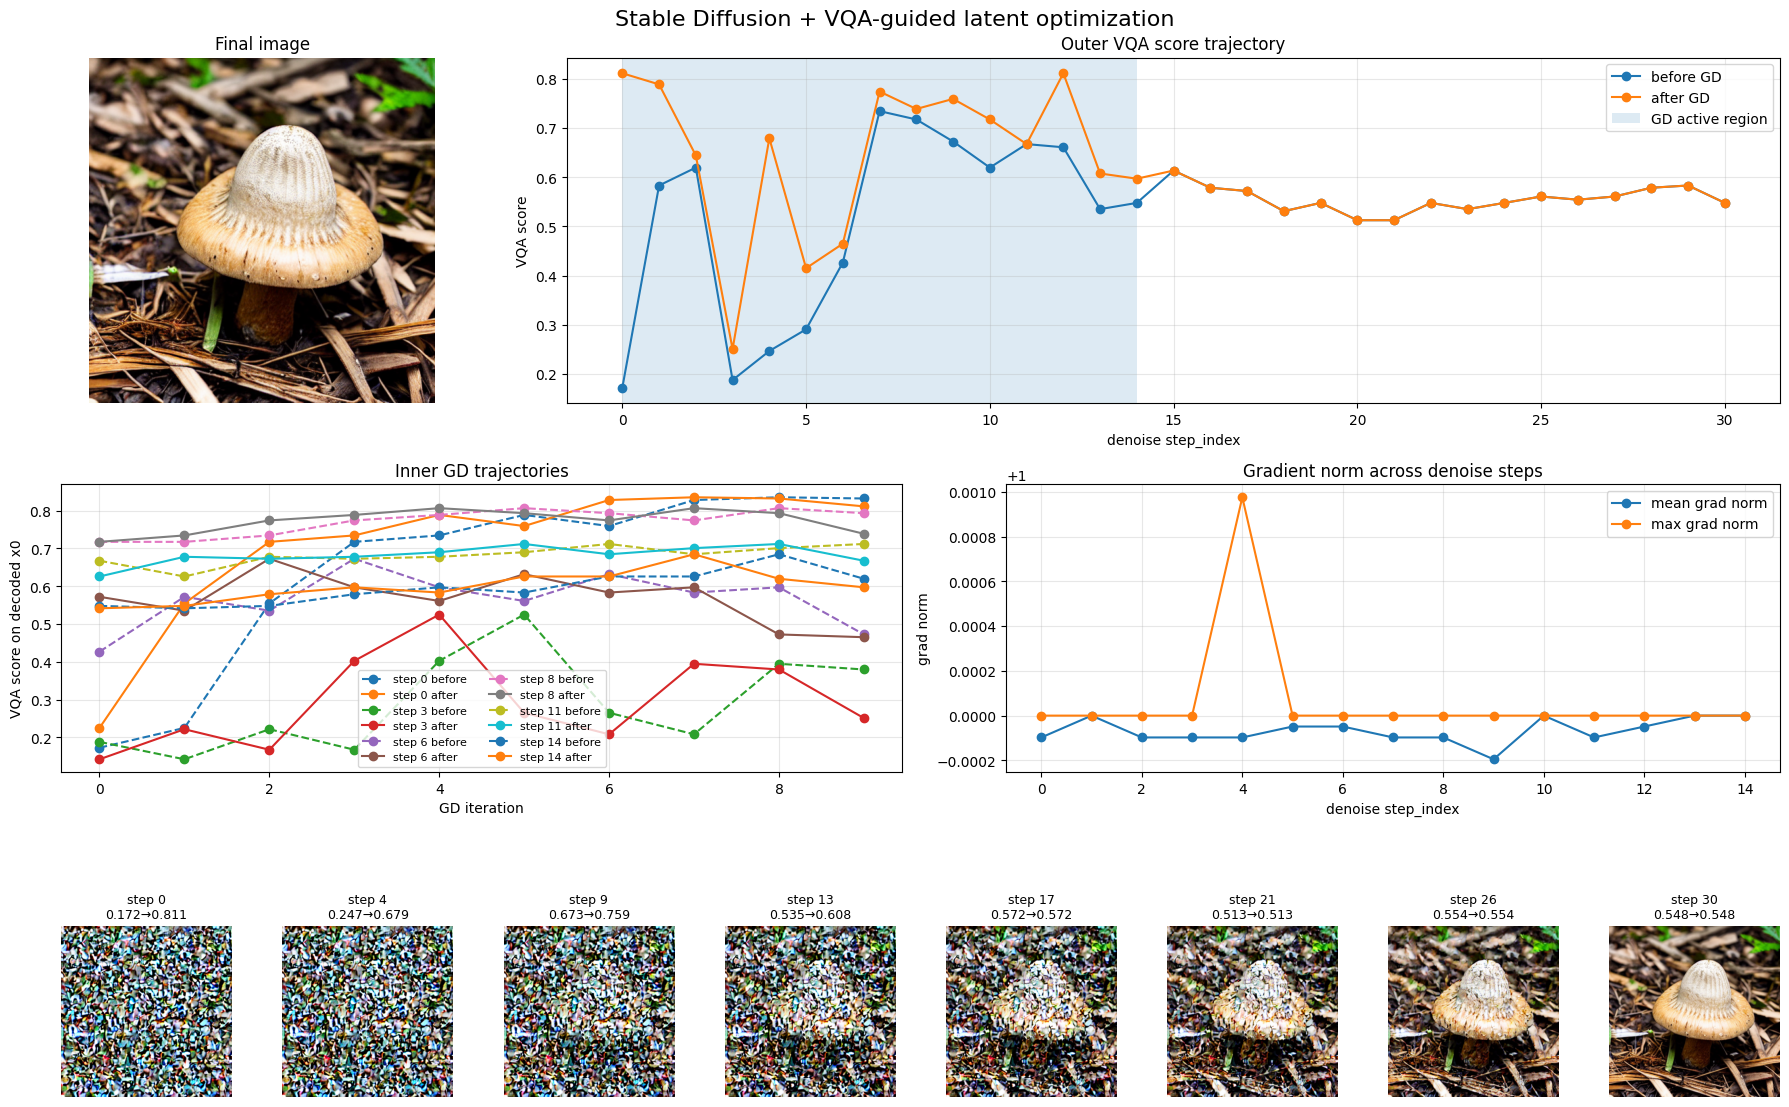

In [8]:
plot_generation_summary(
    final_images=final_images,
    step_scores=step_scores,
    max_inner_plots=6,
    max_step_thumbs=8,
    figsize=(18, 12),
    save_path="sd15_vqa_gd_run/summary_plot.png",
)